Formulas del sistema

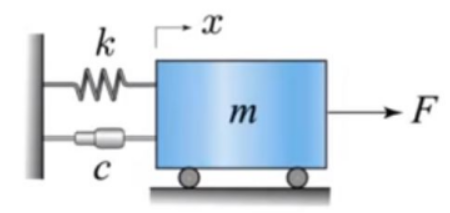

$ m\ddot{x} + c\dot{x} + kx = F \qquad \dot{\mathbf{x}} = \begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \end{bmatrix} = \begin{bmatrix} x_2 \\ -\dfrac{k}{m}x_1 - \dfrac{c}{m}x_2 + \dfrac{1}{m}F \end{bmatrix} \qquad F = 0 $

Importo librerias

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Defino constantes del sistena

In [24]:
# Parámetros del sistema 
m    = 3.5           # Masa (Ton)
k    = 590.339       # Rigidez del sistema (kN/m)
xi_1 = 0             # Coeficiente de amortiguamiento critico 1
xi_2 = 0.05          # Coeficiente de amortiguamiento critico 2
xi_3 = 0.25          # Coeficiente de amortiguamiento critico 3
w    = np.sqrt(k/m)  # Frecuencia natural del sistema (rad/s)

# Condiciones iniciales
x0  = 0.1                    # Posición inicial (m)
v0  = 5                      # Velocidad inicial (m/s)
X_0 = np.array([x0, v0])     # Vector de condiciones iniciales

# Parámetros de simulación
t0 = 0.0                       # Tiempo inicial (s)
tf = 5.0                       # Tiempo final (s)
h  = 0.01                      # Paso de integración
t_eval = np.arange(t0, tf, h)  # Vector de tiempo para evaluar la solución (usado para la solucion con Scipy)

Definicion ecuaciones del sistema dependiendo el coef de amortiguamiento critico

In [25]:
# Sistema de ecuaciones de primer orden (aplicando sustitucion o cambio de variables)

# |dx/dt  |  = |          x_2         |
# |d2x/dt2|  = |(-2*w*xi*x_2 - k*x_1) |
def Funcion_sistema_1(t, X):
    return np.array([X[1],
                     -2*w*xi_1*X[1] - w**2*X[0]])

def Funcion_sistema_2(t, X):
    return np.array([X[1],
                     -2*w*xi_2*X[1] - w**2*X[0]])

def Funcion_sistema_3(t, X):
    return np.array([X[1],
                     -2*w*xi_3*X[1] - w**2*X[0]])

Solucion usando la librería SciPy

In [26]:
# Resolucion de la ecuacion diferencial usando RK45 (debido a que la librería no cuenta directamente con el RK4 sino con un RK 4to/5to grado)
sol_1 = solve_ivp(Funcion_sistema_1, [t0, tf], X_0, method='RK45', t_eval=t_eval)
sol_2 = solve_ivp(Funcion_sistema_2, [t0, tf], X_0, method='RK45', t_eval=t_eval)
sol_3 = solve_ivp(Funcion_sistema_3, [t0, tf], X_0, method='RK45', t_eval=t_eval)

# Desempaqueto las soluciones
t_1, x_values_1, v_values_1 = sol_1.t, sol_1.y[0], sol_1.y[1]
t_2, x_values_2, v_values_2 = sol_2.t, sol_2.y[0], sol_2.y[1]
t_3, x_values_3, v_values_3 = sol_3.t, sol_3.y[0], sol_3.y[1]

# Calcular la aceleración para cada solución
a_values_1 = -2*w*xi_1*v_values_1 - w**2*x_values_1
a_values_2 = -2*w*xi_2*v_values_2 - w**2*x_values_2
a_values_3 = -2*w*xi_3*v_values_3 - w**2*x_values_3

# 4) Grafica de la variacion de la posicion, velocidad y aceleracion respecto al tiempo para cada amortiguamiento

In [27]:
# Funciones para graficar la solucion
def Grafica_x(t, x_values, xi):
    plt.figure(figsize=(10, 5))
    plt.plot(t, x_values, label="Posición x(t)", color="b")
    plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Desplazamiento (m)")
    plt.title(f"Desplazamiento vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi}")
    plt.legend()
    plt.grid()
    plt.show()

def Grafica_v(t, v_values, xi):
    plt.figure(figsize=(10, 5))
    plt.plot(t, v_values, label="Velocidad v(t)", color="r")
    plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Velocidad (m/s)")
    plt.title(f"Velocidad vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi}")
    plt.legend()
    plt.grid()
    plt.show()

def Grafica_a(t, a_values, xi):
    plt.figure(figsize=(10, 5))
    plt.plot(t, a_values, label="Aceleración a(t)", color="g")
    plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Aceleración (m/s²)")
    plt.title(f"Aceleración vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi}")
    plt.legend()
    plt.grid()
    plt.show()

## Graficas para $\xi$ = 0 %

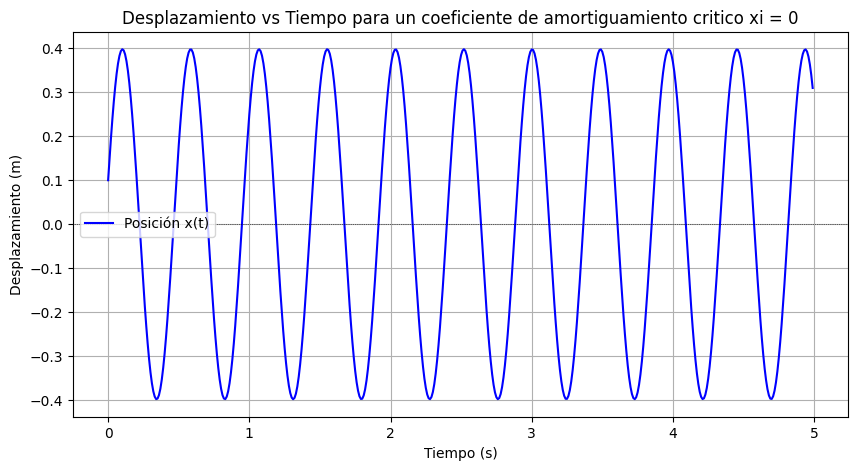

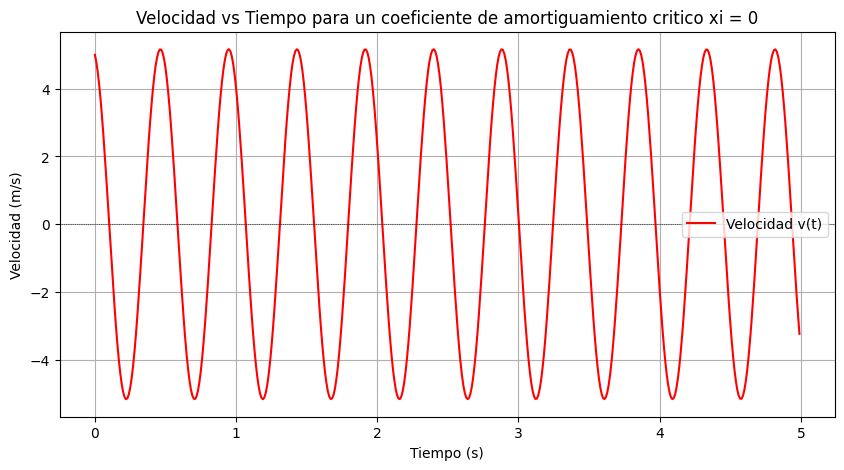

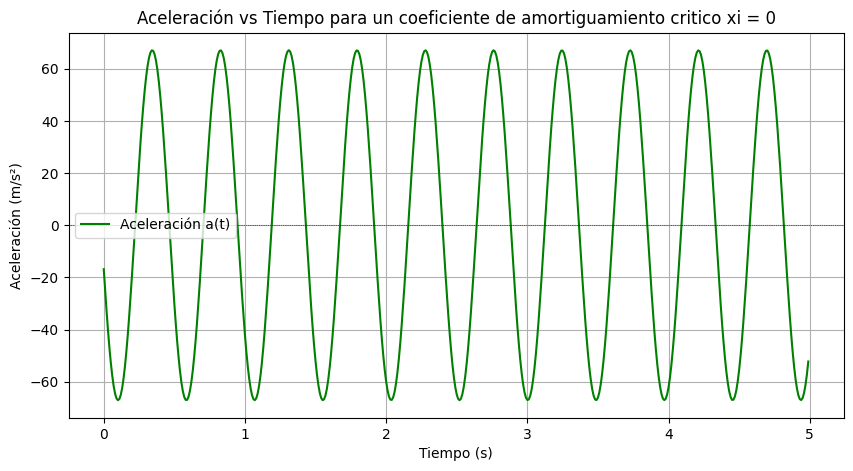

In [28]:
Grafica_x(t_1, x_values_1, xi_1)
Grafica_v(t_1, v_values_1, xi_1)
Grafica_a(t_1, a_values_1, xi_1)

## Graficas para $\xi$ = 5 %

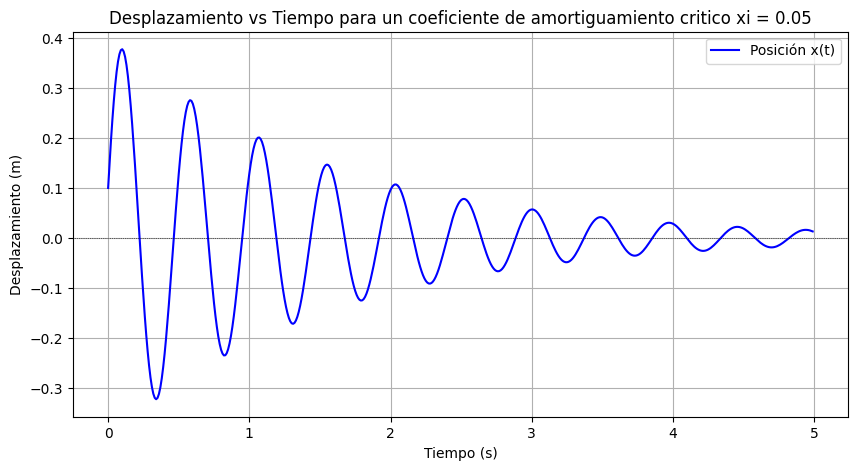

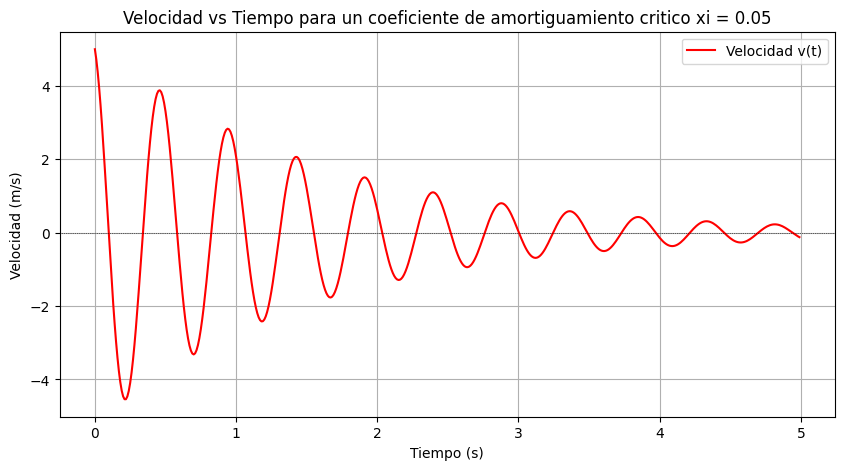

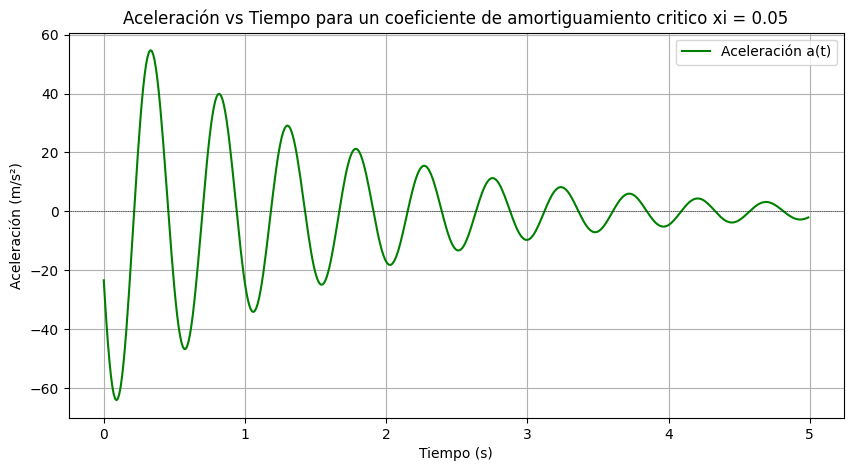

In [29]:
Grafica_x(t_2, x_values_2, xi_2)
Grafica_v(t_2, v_values_2, xi_2)
Grafica_a(t_2, a_values_2, xi_2)

## Graficas para $\xi$ = 25 %

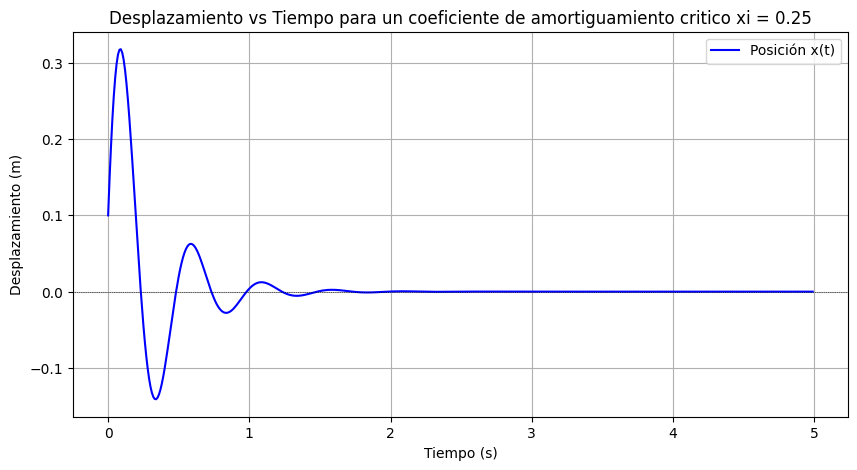

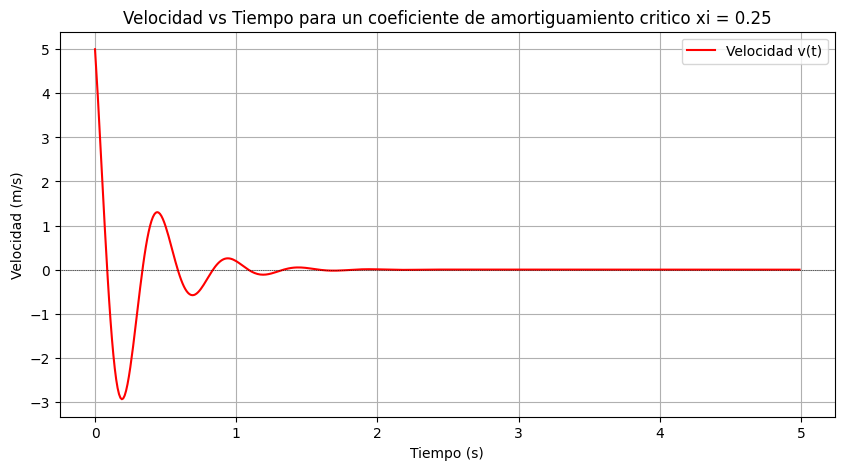

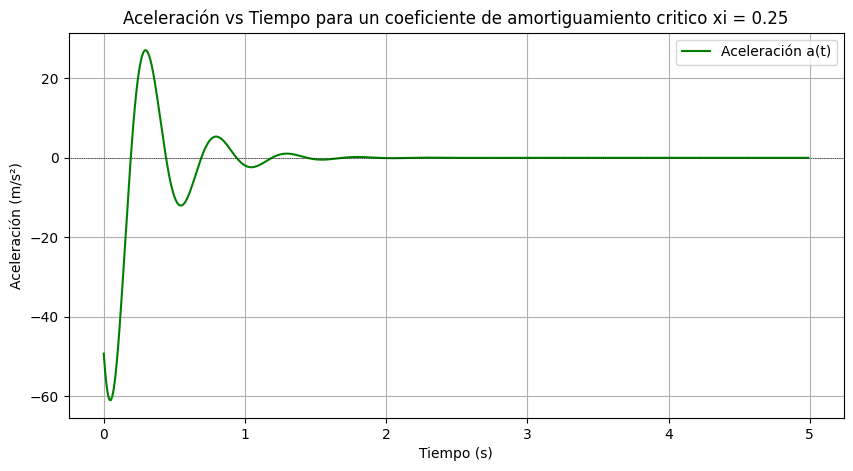

In [30]:
Grafica_x(t_3, x_values_3, xi_3)
Grafica_v(t_3, v_values_3, xi_3)
Grafica_a(t_3, a_values_3, xi_3)

# 5) Graficas de fuerzas del sistema vs tiempo para cada amortiguamiento

Definicion de las fuerzas

In [31]:
# Formula fuerza inercial: Fi = m*a = m*(d2x/dt2)
Fi_1 = m*a_values_1
Fi_2 = m*a_values_2
Fi_3 = m*a_values_3

# Formula de la fuerza de amortiguamiento: Fd = 2*xi*m*w*v = 2*m*w*xi*(dx/dt)
Fd_1 = 2*m*w*xi_1*v_values_1
Fd_2 = 2*m*w*xi_2*v_values_2
Fd_3 = 2*m*w*xi_3*v_values_3

# Formula de la fuerza restauradora: Fr = k*x
Fr_1 = k*x_values_1
Fr_2 = k*x_values_2
Fr_3 = k*x_values_3

In [32]:
# Funciones para graficar las fuerzas

def Grafica_Fi(t, x_values, xi):
    plt.figure(figsize=(10, 5))
    plt.plot(t, x_values, label="Fuerza inercial (Fi)", color="b")
    plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Fuerza (kN)")
    plt.title(f"Fuerza inercial vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi}")
    plt.legend()
    plt.grid()
    plt.show()

def Grafica_Fd(t, x_values, xi):
    plt.figure(figsize=(10, 5))
    plt.plot(t, x_values, label="Fuerza de amortiguamiento (Fd)", color="r")
    plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Fuerza (kN)")
    plt.title(f"Fuerza de amortiguamiento vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi}")
    plt.legend()
    plt.grid()
    plt.show()

def Grafica_Fr(t, x_values, xi):
    plt.figure(figsize=(10, 5))
    plt.plot(t, x_values, label="Fuerza restauradora (Fr)", color="g")
    plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Fuerza (kN)")
    plt.title(f"Fuerza restauradora vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi}")
    plt.legend()
    plt.grid()
    plt.show()

## Graficas para $\xi$ = 0 %

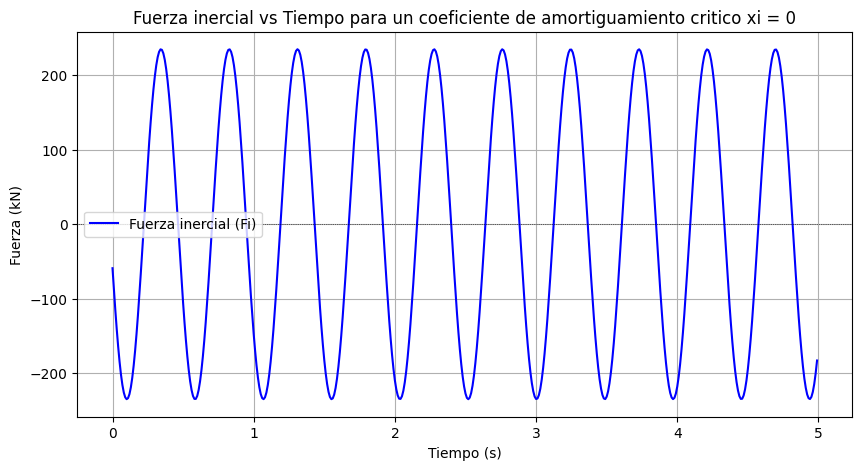

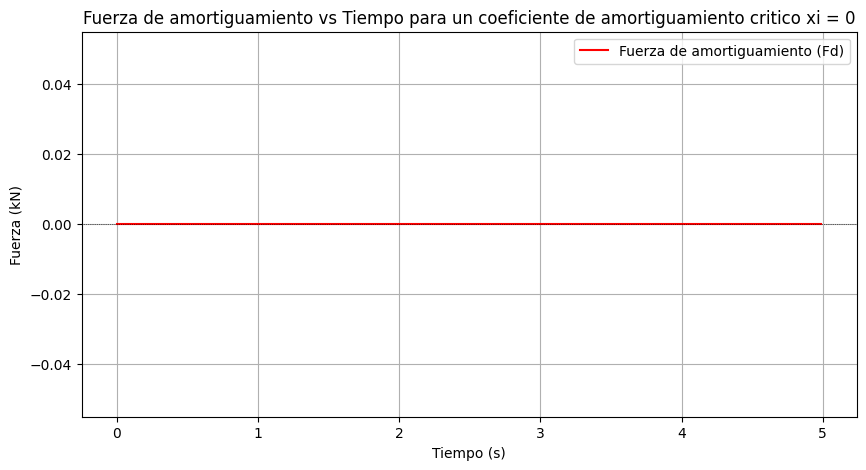

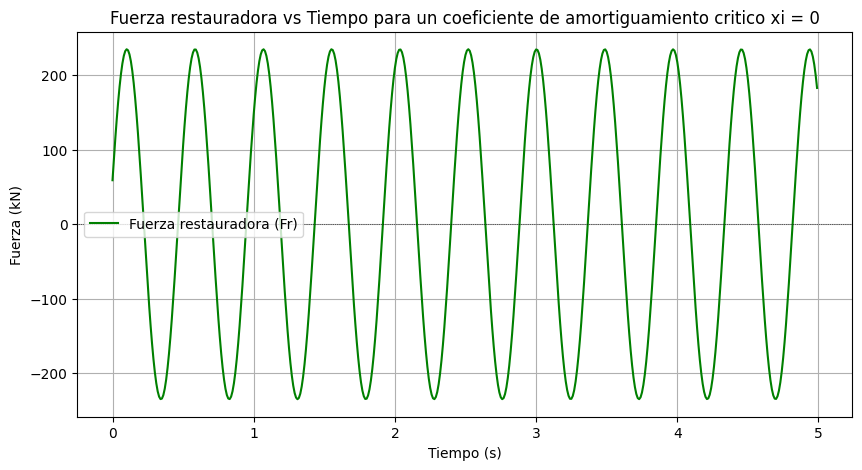

In [33]:
Grafica_Fi(t_1, Fi_1, xi_1)
Grafica_Fd(t_1, Fd_1, xi_1)
Grafica_Fr(t_1, Fr_1, xi_1)

## Graficas para $\xi$ = 5 %

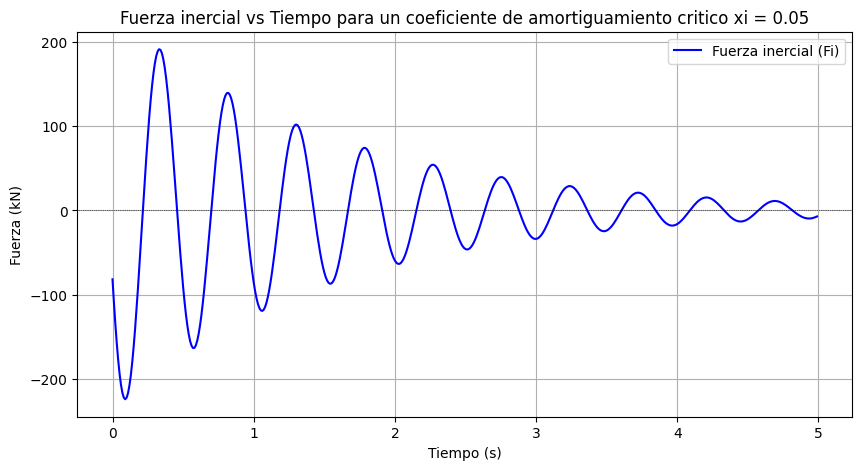

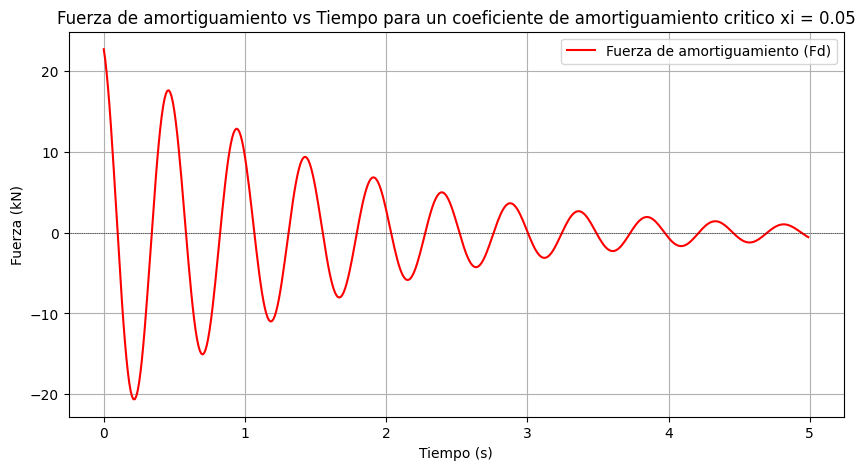

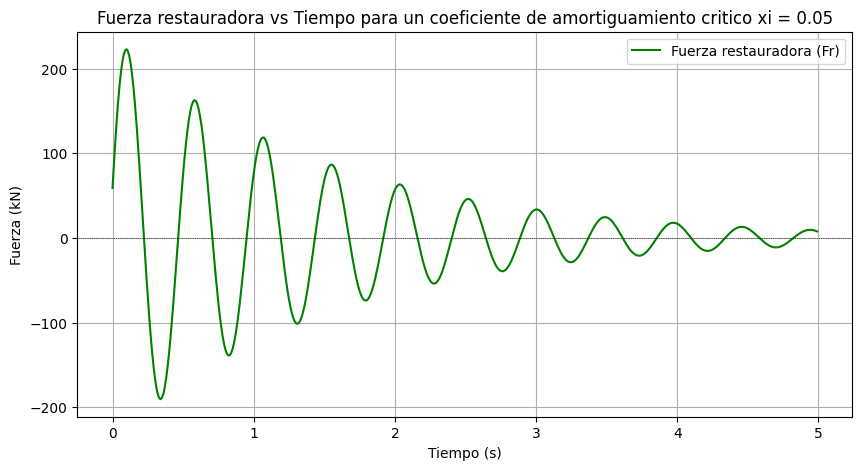

In [34]:
Grafica_Fi(t_2, Fi_2, xi_2)
Grafica_Fd(t_2, Fd_2, xi_2)
Grafica_Fr(t_2, Fr_2, xi_2)

## Graficas para $\xi$ = 25 %

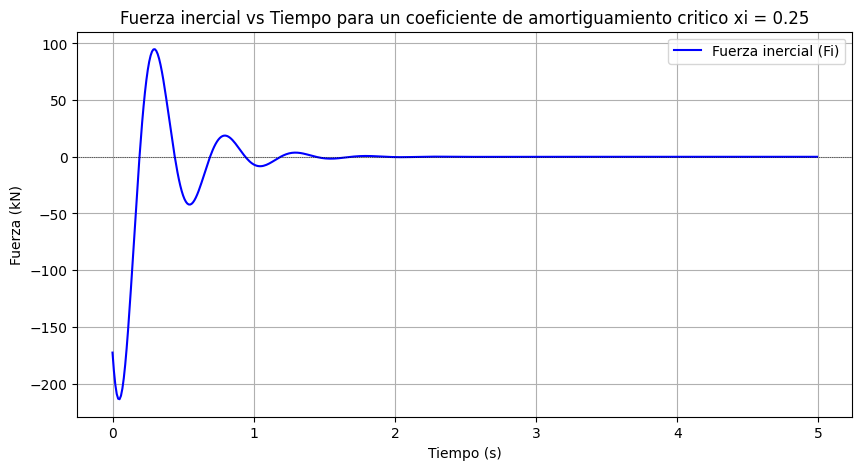

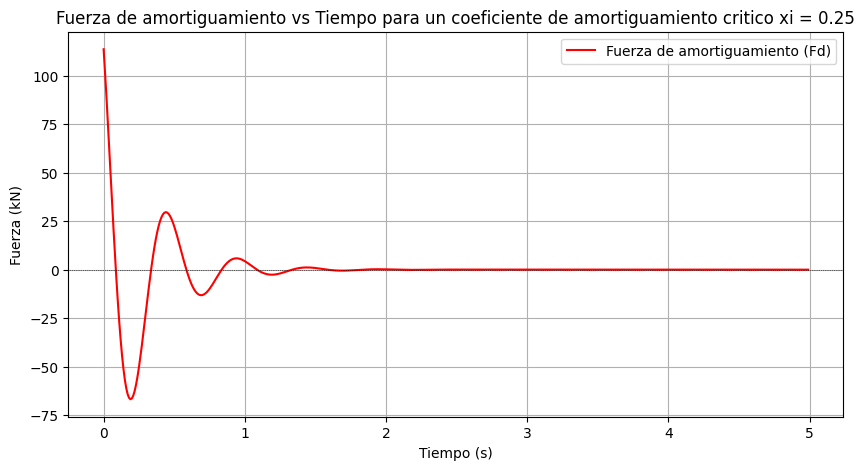

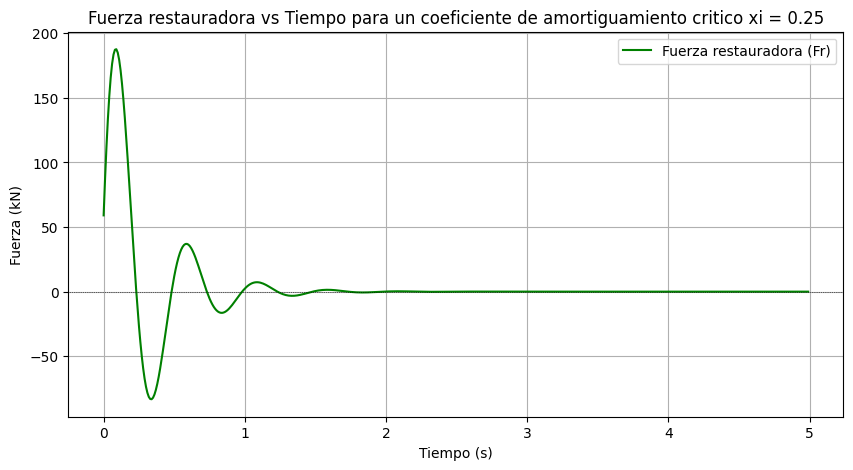

In [35]:
Grafica_Fi(t_3, Fi_3, xi_3)
Grafica_Fd(t_3, Fd_3, xi_3)
Grafica_Fr(t_3, Fr_3, xi_3)

# 6) Graficas equilibrio dinamico o principio de D'Alemberg para cada amortiguamiento

## Graficas para $\xi$ = 0 % 

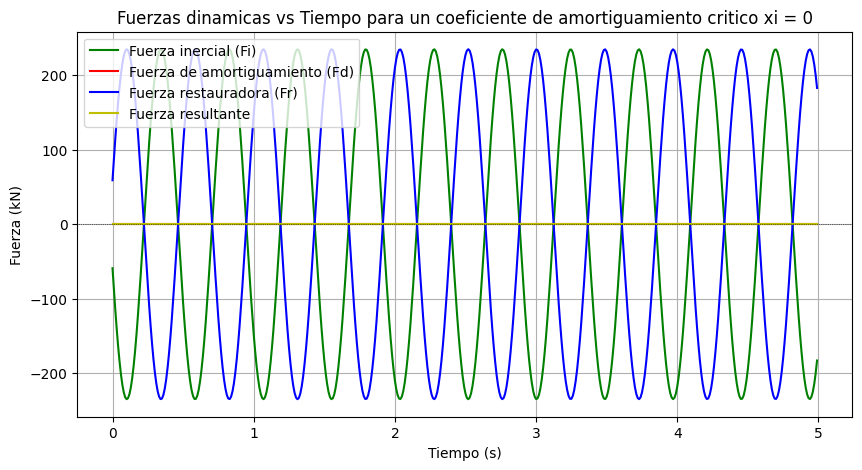

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(t_1, Fi_1, label="Fuerza inercial (Fi)", color="g")
plt.plot(t_1, Fd_1, label="Fuerza de amortiguamiento (Fd)", color="r")
plt.plot(t_1, Fr_1, label="Fuerza restauradora (Fr)", color="b")
plt.plot(t_1, Fi_1 + Fd_1 + Fr_1, label="Fuerza resultante ", color="y")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Fuerza (kN)")
plt.title(f"Fuerzas dinamicas vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi_1}")
plt.legend()
plt.grid()
plt.show()

## Graficas para $\xi$ = 5 % 

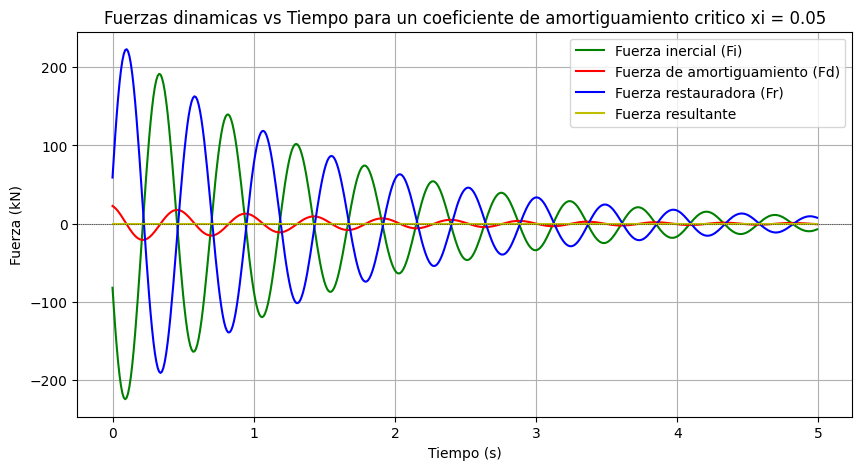

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(t_2, Fi_2, label="Fuerza inercial (Fi)", color="g")
plt.plot(t_2, Fd_2, label="Fuerza de amortiguamiento (Fd)", color="r")
plt.plot(t_2, Fr_2, label="Fuerza restauradora (Fr)", color="b")
plt.plot(t_2, Fi_2 + Fd_2 + Fr_2, label="Fuerza resultante ", color="y")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Fuerza (kN)")
plt.title(f"Fuerzas dinamicas vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi_2}")
plt.legend()
plt.grid()
plt.show()

## Graficas para $\xi$ = 25 % 

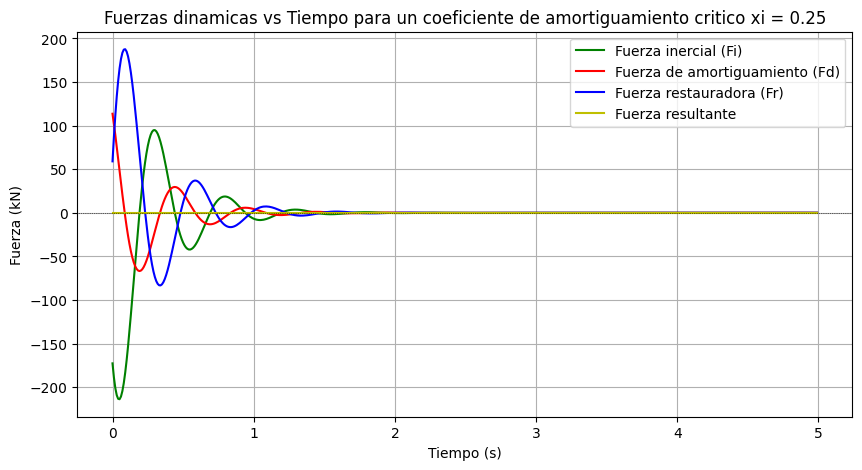

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(t_3, Fi_3, label="Fuerza inercial (Fi)", color="g")
plt.plot(t_3, Fd_3, label="Fuerza de amortiguamiento (Fd)", color="r")
plt.plot(t_3, Fr_3, label="Fuerza restauradora (Fr)", color="b")
plt.plot(t_3, Fi_3 + Fd_3 + Fr_3, label="Fuerza resultante ", color="y")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Fuerza (kN)")
plt.title(f"Fuerzas dinamicas vs Tiempo para un coeficiente de amortiguamiento critico xi = {xi_3}")
plt.legend()
plt.grid()
plt.show()


# 7) Comparacion resultados obtenidos según los distintos amortiguamientos

## Desplazamiento 

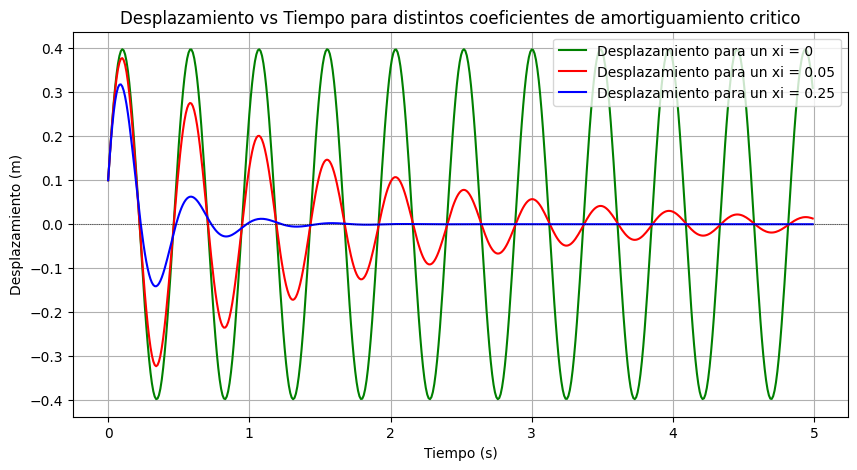

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(t_1, x_values_1, label=f"Desplazamiento para un xi = {xi_1}", color="g")
plt.plot(t_2, x_values_2, label=f"Desplazamiento para un xi = {xi_2}", color="r")
plt.plot(t_3, x_values_3, label=f"Desplazamiento para un xi = {xi_3}", color="b")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Desplazamiento (m)")
plt.title("Desplazamiento vs Tiempo para distintos coeficientes de amortiguamiento critico")
plt.legend()
plt.grid()
plt.show()

## Velocidad

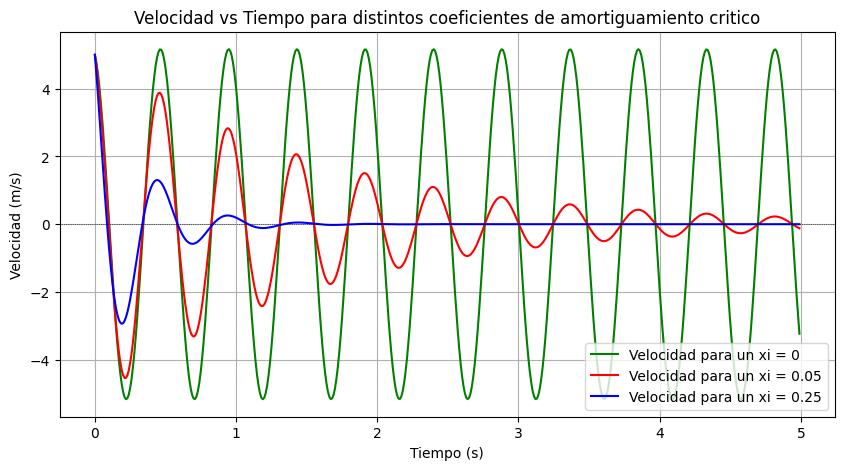

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(t_1, v_values_1, label=f"Velocidad para un xi = {xi_1}", color="g")
plt.plot(t_2, v_values_2, label=f"Velocidad para un xi = {xi_2}", color="r")
plt.plot(t_3, v_values_3, label=f"Velocidad para un xi = {xi_3}", color="b")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (m/s)")
plt.title("Velocidad vs Tiempo para distintos coeficientes de amortiguamiento critico")
plt.legend()
plt.grid()
plt.show()

## Aceleración

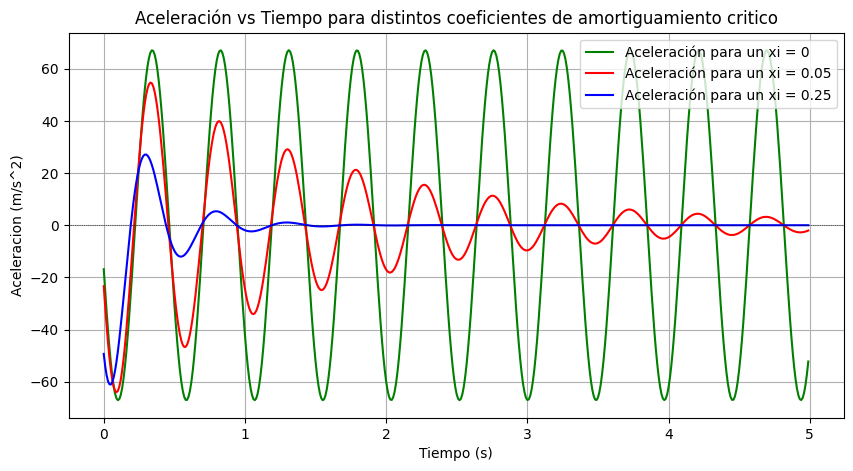

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(t_1, a_values_1, label=f"Aceleración para un xi = {xi_1}", color="g")
plt.plot(t_2, a_values_2, label=f"Aceleración para un xi = {xi_2}", color="r")
plt.plot(t_3, a_values_3, label=f"Aceleración para un xi = {xi_3}", color="b")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Aceleracion (m/s^2)")
plt.title("Aceleración vs Tiempo para distintos coeficientes de amortiguamiento critico")
plt.legend()
plt.grid()
plt.show()

## Fuerza inercial

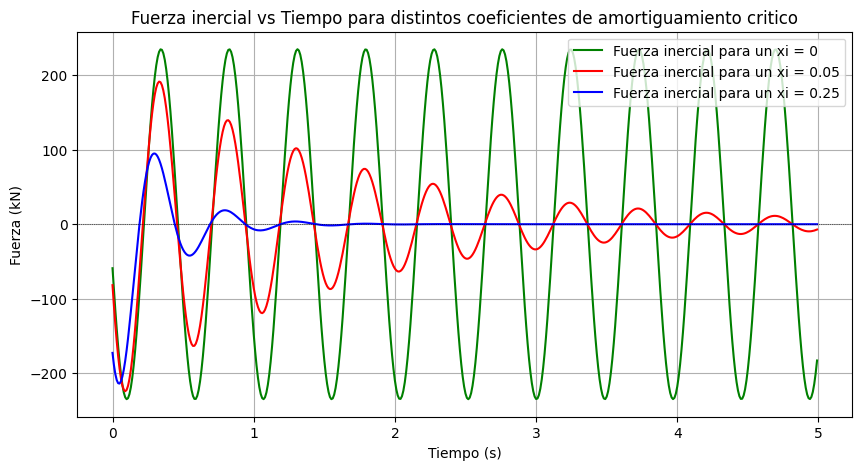

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(t_1, Fi_1, label=f"Fuerza inercial para un xi = {xi_1}", color="g")
plt.plot(t_2, Fi_2, label=f"Fuerza inercial para un xi = {xi_2}", color="r")
plt.plot(t_3, Fi_3, label=f"Fuerza inercial para un xi = {xi_3}", color="b")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Fuerza (kN)")
plt.title("Fuerza inercial vs Tiempo para distintos coeficientes de amortiguamiento critico")
plt.legend()
plt.grid()
plt.show()

## Fuerza amortiguadora

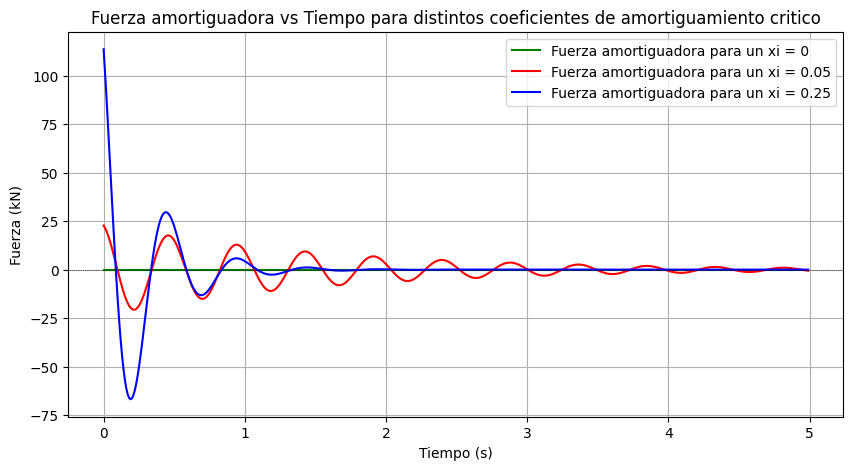

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(t_1, Fd_1, label=f"Fuerza amortiguadora para un xi = {xi_1}", color="g")
plt.plot(t_2, Fd_2, label=f"Fuerza amortiguadora para un xi = {xi_2}", color="r")
plt.plot(t_3, Fd_3, label=f"Fuerza amortiguadora para un xi = {xi_3}", color="b")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Fuerza (kN)")
plt.title("Fuerza amortiguadora vs Tiempo para distintos coeficientes de amortiguamiento critico")
plt.legend()
plt.grid()
plt.show()

## Fuerza restauradora

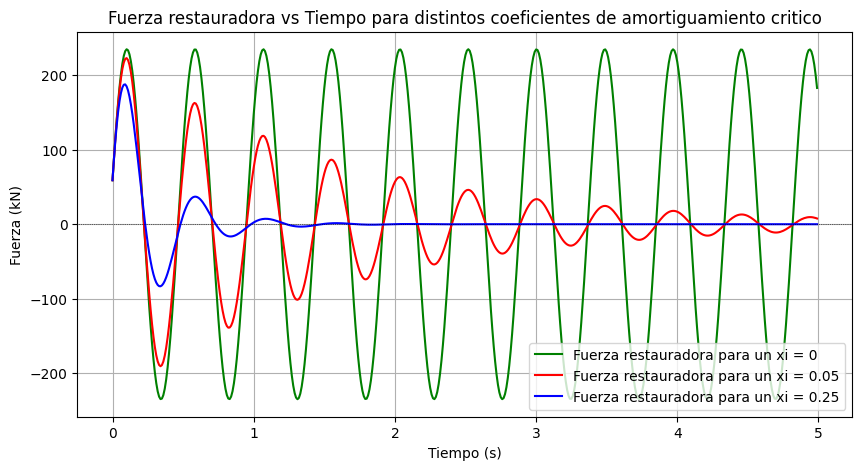

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(t_1, Fr_1, label=f"Fuerza restauradora para un xi = {xi_1}", color="g")
plt.plot(t_2, Fr_2, label=f"Fuerza restauradora para un xi = {xi_2}", color="r")
plt.plot(t_3, Fr_3, label=f"Fuerza restauradora para un xi = {xi_3}", color="b")
plt.axhline(0, color='black', linewidth=0.5, linestyle='dotted')
plt.xlabel("Tiempo (s)")
plt.ylabel("Fuerza (kN)")
plt.title("Fuerza restauradora vs Tiempo para distintos coeficientes de amortiguamiento critico")
plt.legend()
plt.grid()
plt.show()